In [1]:
import numpy as np
import pandas as pd

import simulator
import generator
import eval

import matplotlib.pyplot as plt

## Ground Truth Series

In [2]:
NSIM = 100
LEN_HIST = 252
LEN_SEED = 25
LOOKBACK = 20
LEN_FUTURE = 60

In [3]:
"""GBM"""
sim_args = {
    'mu': 0.10,
    'sigma': 0.30,
    'dt' : 1/252,
    'seed': 42
}
# generate an observable path
hist_price = simulator.gbm(N=1, T=LEN_HIST, S0=100, **sim_args)[0]
hist_logret = simulator.prices_to_logreturns(hist_price, axis=-1)

# simulate future paths from ground thruth
fut_prices = simulator.gbm(N=NSIM, T=LEN_FUTURE, S0=hist_price[-1], **sim_args)
fut_logrets = simulator.prices_to_logreturns(fut_prices, axis=-1)

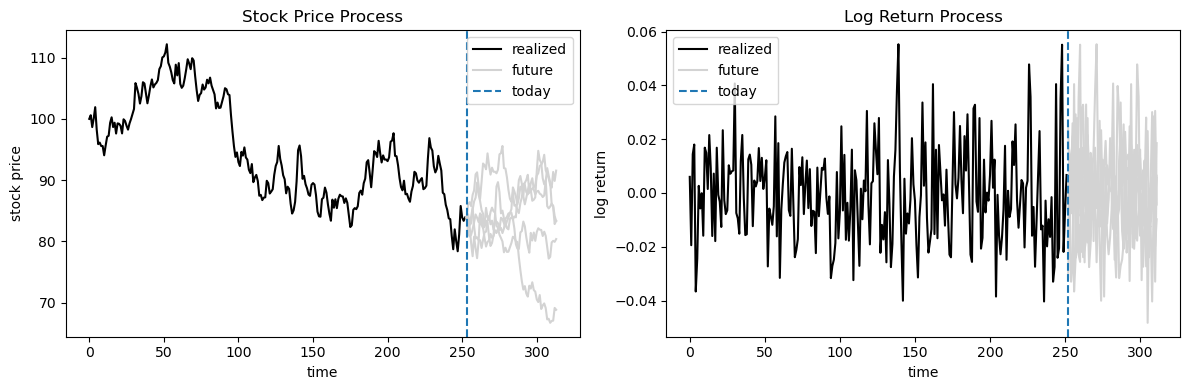

In [4]:
eval.plot_true_series(hist_price, hist_logret, fut_prices[:10], fut_logrets[:10])

## Generate Series with Different Generators

In [5]:
gen_logret = dict()
gen_price = dict()

In [6]:
# Pathwise Bootstrap
gen_bs = generator.BootstrapPathwise(
    lookback=LOOKBACK, sig_level=2, forward=5, dt=1, k=10,
    neighbor_weighting="softmax", random_state=42
).fit_logrets([hist_logret])

gen_logret['bootstrap'] = np.array([
    gen_bs.generate_logrets(
        seed_path=hist_logret[-LEN_SEED:], n_total_steps=LEN_SEED+LEN_FUTURE, return_full_path=False
    ) for _ in range(NSIM)])
gen_price['bootstrap'] = generator.logrets_to_prices(gen_logret['bootstrap'], hist_price[-1])[:,1:]

100%|██████████| 227/227 [00:00<00:00, 19520.39it/s]


In [7]:
# Hybrid KRR and Bootstrap
gen_hb = generator.HybridKRRBootstrap(
    lookback=LOOKBACK, sig_level=2, dt=1, k=10, lam = 1,
    neighbor_weighting="softmax", random_state=42
).fit_logrets([hist_logret])

gen_logret['hybrid'] = np.array([
    gen_hb.generate_logrets(
        seed_path=hist_logret[-LEN_SEED:], n_total_steps=LEN_SEED+LEN_FUTURE, return_full_path=False
    ) for _ in range(NSIM)])
gen_price['hybrid'] = generator.logrets_to_prices(gen_logret['hybrid'], hist_price[-1])[:,1:]

100%|██████████| 232/232 [00:00<00:00, 2483.22it/s]


In [8]:
# KRR
gen_krr = generator.KRRSignature(
    lookback=LOOKBACK, sig_level=2, dt=1, lam_mu = 1, lam_sig = 1, random_state=42
).fit_logrets([hist_logret])

gen_logret['krr'] = np.array([
    gen_krr.generate_logrets(
        seed_path=hist_logret[-LEN_SEED:], n_total_steps=LEN_SEED+LEN_FUTURE, return_full_path=False
    ) for _ in range(NSIM)])
gen_price['krr'] = generator.logrets_to_prices(gen_logret['krr'], hist_price[-1])[:,1:]

In [9]:
# ARIMA
gen_arima = generator.ARIMAGen(order=(1,0,1), trend='c', random_state=42).fit_logrets(hist_logret)

gen_logret['arima'] = np.array([gen_arima.generate_logrets(n_steps=LEN_FUTURE) for _ in range(NSIM)])
gen_price['arima'] = generator.logrets_to_prices(gen_logret['arima'], hist_price[-1])[:,1:]

In [10]:
# GARCH
gen_garch = generator.GARCHGen(p=1,q=1,dist='t',random_state=42,scale='auto').fit_logrets(hist_logret)

gen_logret['garch'] = np.array(
    [gen_garch.generate_logrets(n_steps=LEN_FUTURE, seed_returns=hist_logret[-LEN_SEED:]) for _ in range(NSIM)])
gen_price['garch'] = generator.logrets_to_prices(gen_logret['garch'], hist_price[-1])[:,1:]

## Distribution Comparison

Generating method: bootstrap


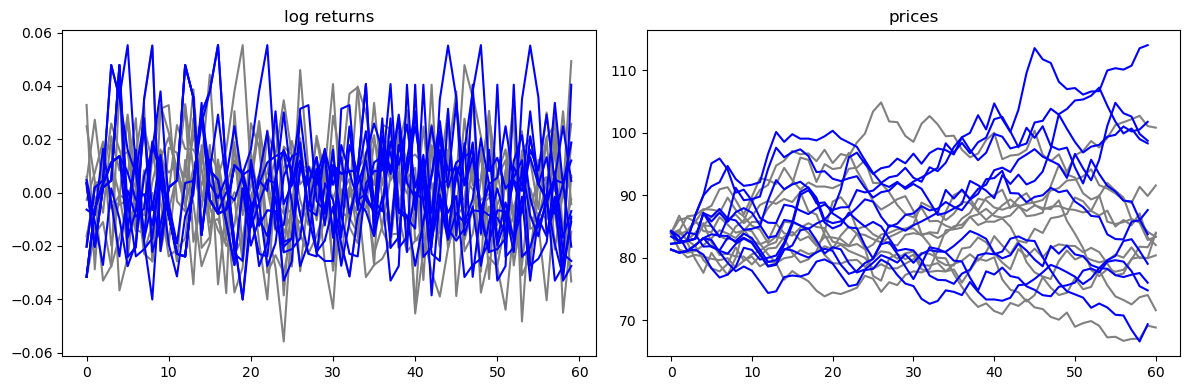

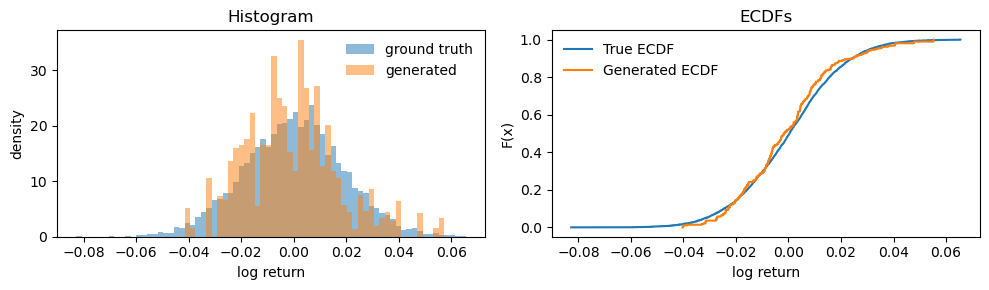

In [11]:
NSHOW = 10
METHOD = 'bootstrap'

print("Generating method:", METHOD)
eval.plot_series_compare(fut_logrets[:NSHOW], fut_prices[:NSHOW], gen_logret[METHOD][:NSHOW], gen_price[METHOD][:NSHOW])
eval.plot_dist_compare(fut_logrets, gen_logret[METHOD])

## Signature MMD

In [12]:
mmd = dict()
for method in gen_price.keys():
    mmd[method] = eval.mmd_signature_linear(
        np.arange(LEN_FUTURE), gen_price[method], fut_prices[:,1:], window_size=5, sig_level=2)

In [13]:
pd.DataFrame(pd.Series(mmd))

,0
bootstrap,0.139669
hybrid,0.035445
krr,1.219328
arima,1.111040
garch,0.754248
